In [53]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import torch
import torchvision
import warnings
warnings.filterwarnings('ignore')

print("torch version : ", torch.__version__)
print("torchvision version : ", torchvision.__version__)

torch version :  2.8.0+cu128
torchvision version :  0.23.0+cu128


In [54]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

Running on: cuda


### Downloading the Dataset and EDA

In [ ]:
#Download data if not yet available
from pathlib import Path
import kagglehub
import shutil

DATA_DIR = Path("../data/bone-fracture-xray")

if DATA_DIR.exists():
    print("Dataset already exists at:", DATA_DIR.resolve())
else:
    print("Dataset not found. Downloading...")

    # KaggleHub handles cache + portability
    cache_path = Path(
        kagglehub.dataset_download("usman44m/bone-fracture-x-ray-dataset")
    )

    DATA_DIR.parent.mkdir(parents=True, exist_ok=True)
    shutil.copytree(cache_path, DATA_DIR)

    print("Dataset ready at:", DATA_DIR.resolve())


Dataset already exists at: /teamspace/studios/this_studio/data/bone-fracture-xray


In [ ]:
train_dir = "../data/bone-fracture-xray/Bone_Fracture_Dataset/train"
val_dir = "../data/bone-fracture-xray/Bone_Fracture_Dataset/val"
test_dir = "../data/bone-fracture-xray/Bone_Fracture_Dataset/test"

In [57]:
import os

# dataset classes
classnames = print(os.listdir(train_dir))


['not fractured', 'fractured']


In [58]:
import random
import math
from PIL import Image

def plot_sample_imgs(data_path, classname, num_images):
    class_dir = os.path.join(data_path, classname)
    
    if not os.path.exists(class_dir): return "Invalid directory"

    image_files = [
        f for f in os.listdir(class_dir)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    num_images = min(num_images, len(image_files))
    images = random.sample(image_files, num_images)

    cols = min(5, num_images)
    rows = math.ceil(num_images / cols)

    # Plotting
    plt.figure(figsize=(4 * cols, 4 * rows))
    plt.title(classname)
    for i, img_name in enumerate(images, 1):
        img_path = os.path.join(class_dir, img_name)
        img = Image.open(img_path)

        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.axis("off")
        

    plt.tight_layout()
    plt.show()

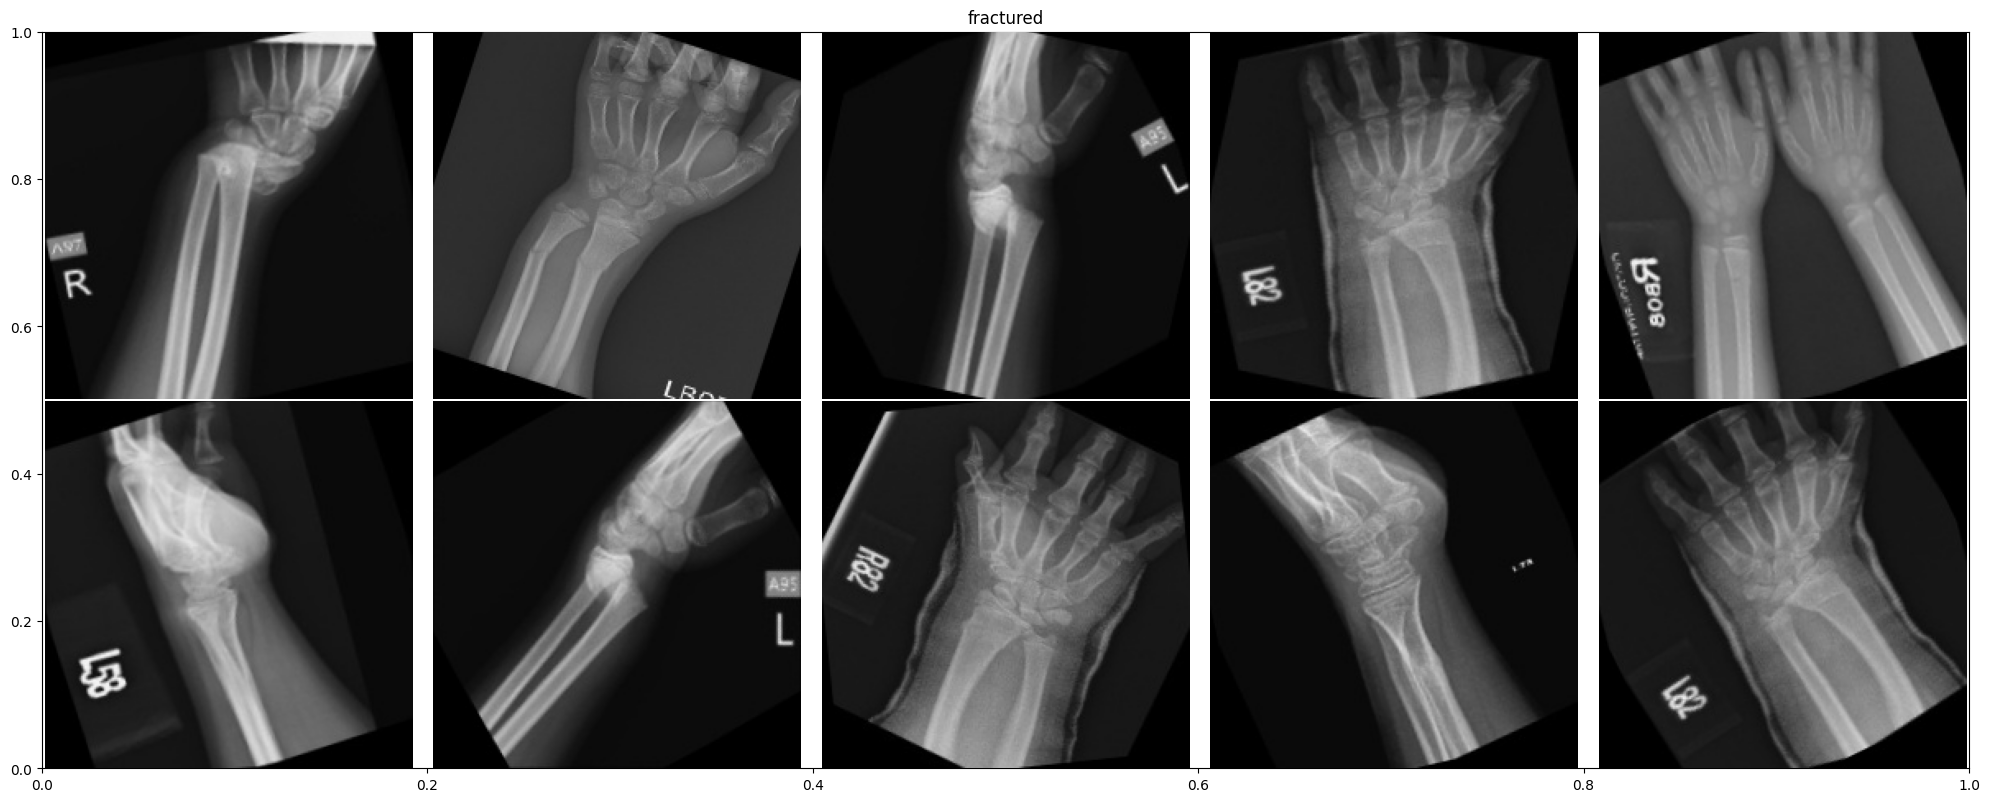

In [59]:
plot_sample_imgs(train_dir, 'fractured', 10)

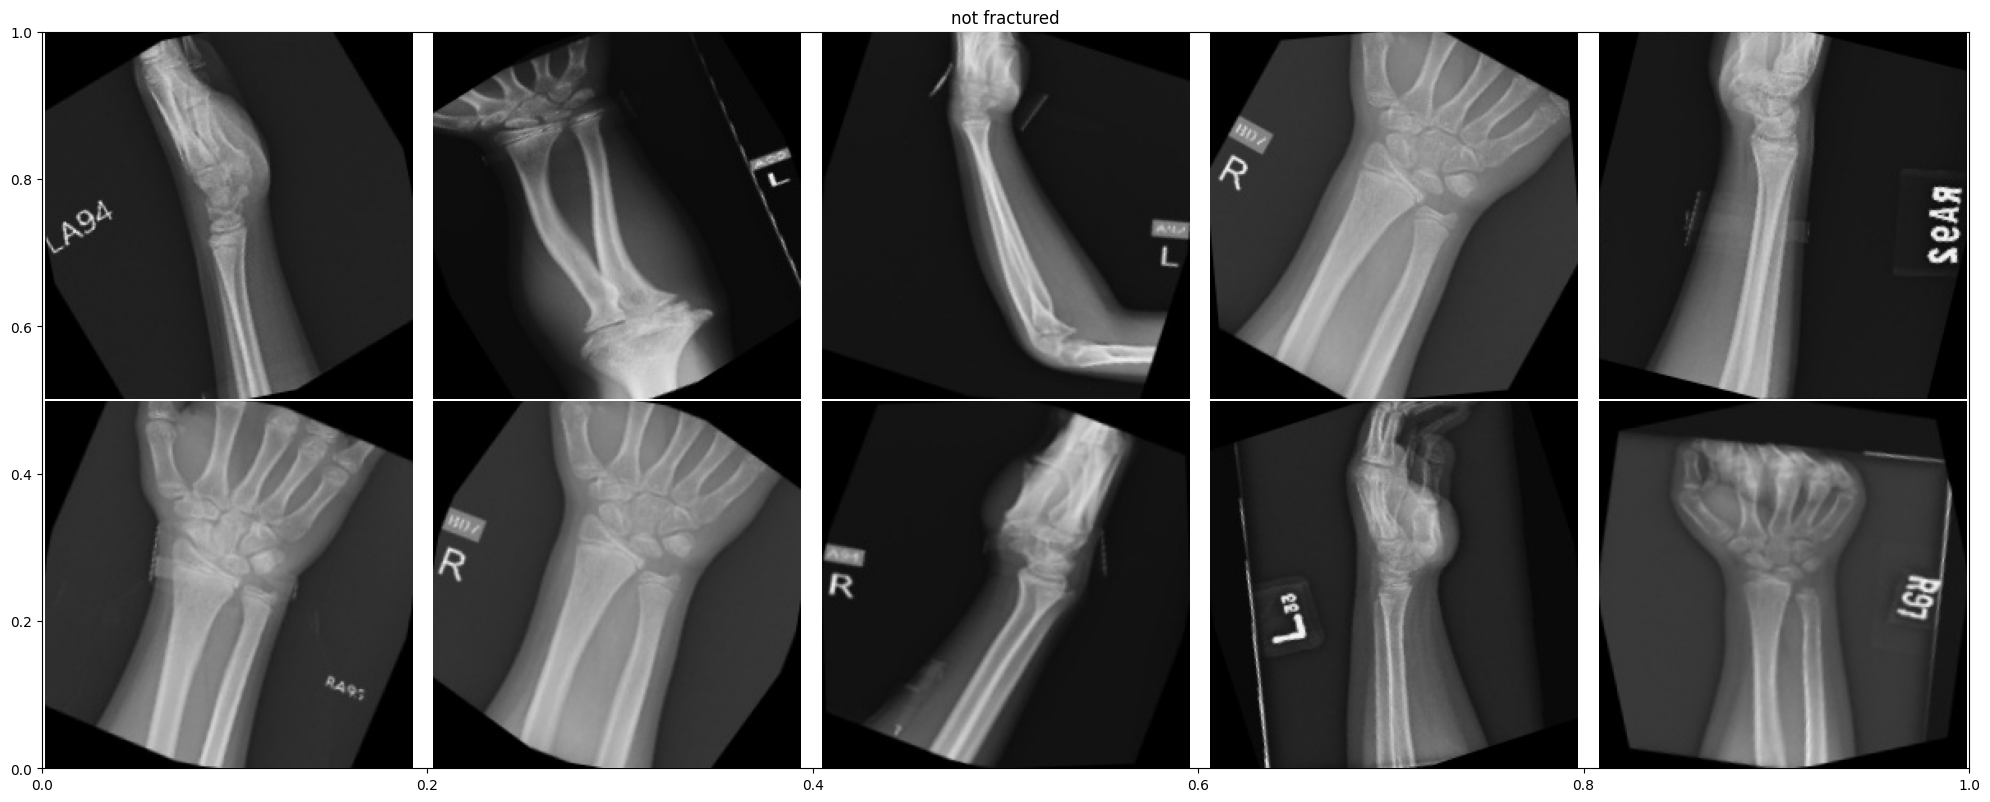

In [60]:
plot_sample_imgs(train_dir, 'not fractured', 10)

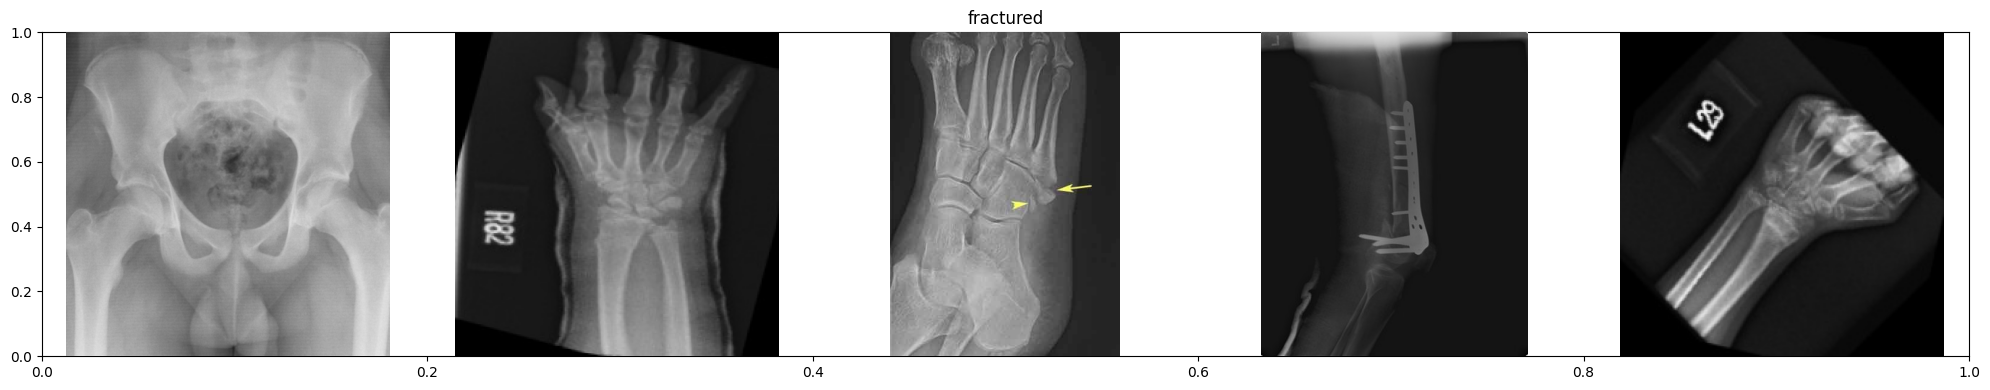

In [61]:
#check all datasets
plot_sample_imgs(val_dir, 'fractured', 5)

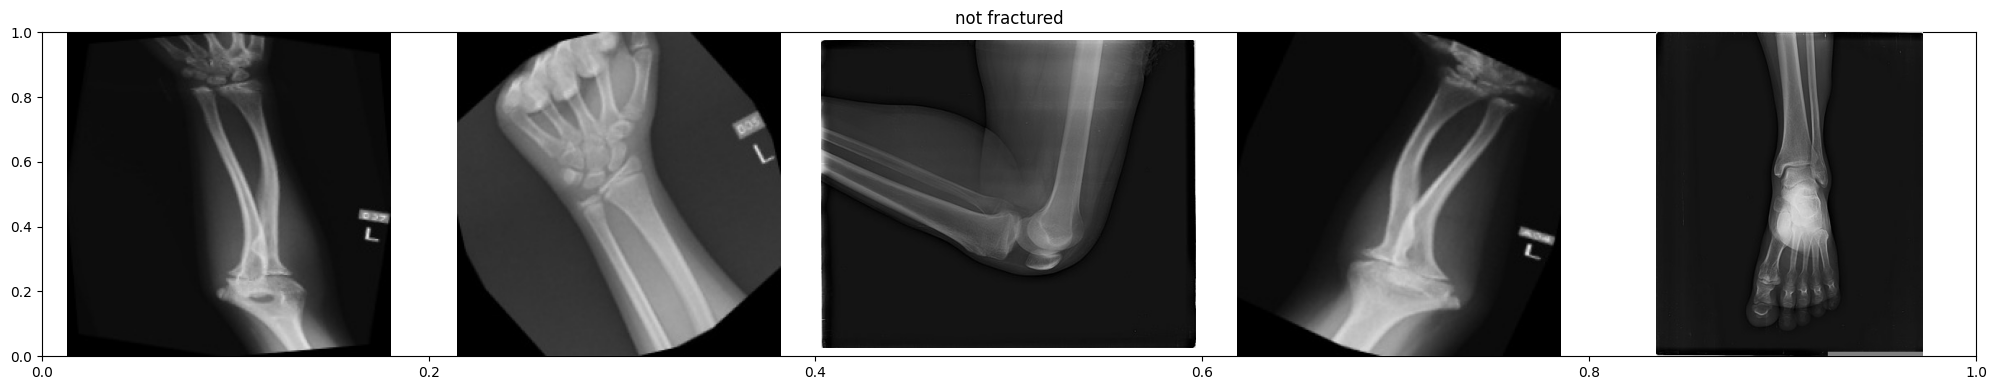

In [62]:
plot_sample_imgs(val_dir, 'not fractured', 5)

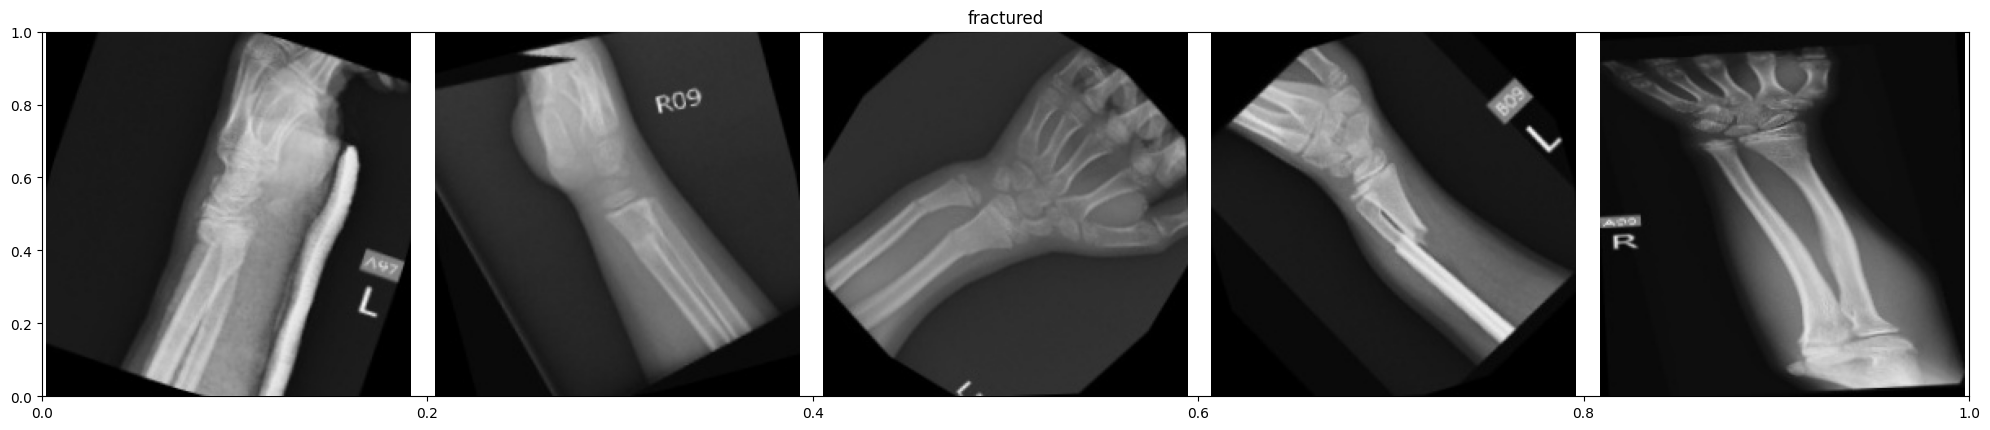

In [63]:
plot_sample_imgs(test_dir, 'fractured', 5)

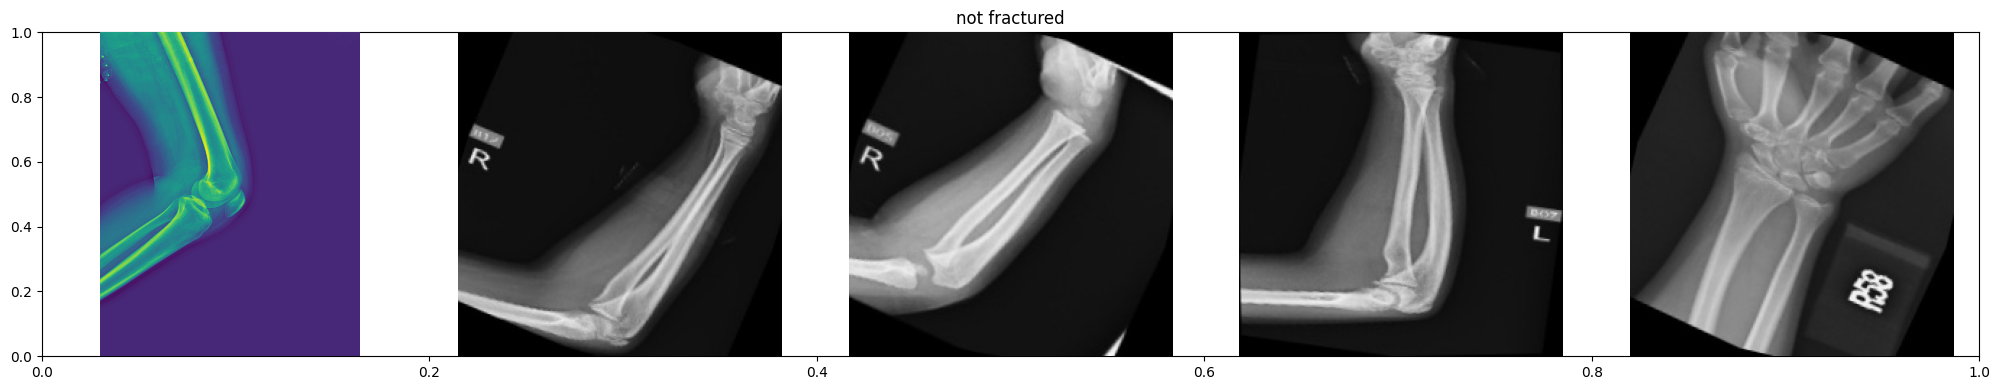

In [64]:
plot_sample_imgs(test_dir, 'not fractured', 5)

In [65]:
#checking dataset sizes and splits

def summarize_split(split_name, split_dir, extensions=(".png", ".jpg", ".jpeg")):
    def count_images(path):
        return len([
            f for f in os.listdir(path)
            if f.lower().endswith(extensions)
        ])

    fractured_dir = os.path.join(split_dir, "fractured")
    not_fractured_dir = os.path.join(split_dir, "not fractured")

    fractured_count = count_images(fractured_dir)
    not_fractured_count = count_images(not_fractured_dir)

    total = fractured_count + not_fractured_count

    frac_pct = (fractured_count / total) * 100 if total > 0 else 0
    not_frac_pct = (not_fractured_count / total) * 100 if total > 0 else 0

    print(f"{split_name} Dataset:")
    print(f"- Total number of images: {total}")
    print(
        f"- Class split: "
        f"{fractured_count} fractured, "
        f"{not_fractured_count} not fractured "
        f"({frac_pct:.1f}% | {not_frac_pct:.1f}%)"
    )
    print()

    return total

In [66]:
grand_total = 0

grand_total += summarize_split("Train", train_dir)
grand_total += summarize_split("Validation", val_dir)
grand_total += summarize_split("Test", test_dir)

print(f"Total number of images in the dataset: {grand_total}")

Train Dataset:
- Total number of images: 9246
- Class split: 4606 fractured, 4640 not fractured (49.8% | 50.2%)

Validation Dataset:
- Total number of images: 829
- Class split: 337 fractured, 492 not fractured (40.7% | 59.3%)

Test Dataset:
- Total number of images: 506
- Class split: 238 fractured, 268 not fractured (47.0% | 53.0%)

Total number of images in the dataset: 10581


The dataset is large and well balanced. 

The images examined look reliable. It seems rotated images were included to make the dataset larger.

# Model Training

I will use a pretrained model, remove the classifier and add my own. Then, I will fine-tune the more successful model.

### Data Prep

In [67]:
import torchvision.models as models
from torchvision import transforms

In [ ]:
#Following another person's notebook (see https://www.kaggle.com/code/asimuddin122/random-forest-got-100) and errors when first trying to train the model, some files need to be ignored

IGNORE = {
    'IMG0004347.jpg',
    'IMG0004148.jpg',
    'IMG0004134.jpg',
    'IMG0004149.jpg',
    'IMG0004143.jpg',
    'IMG0004308.jpg'
}

#only include image files
VALID_EXTS = (".png", ".jpg", ".jpeg")


In [69]:
from torch.utils.data import Dataset

#image data generator
class XRayDataset(Dataset):
    def __init__(self, data_dir, transform=None, ignore_files=None):
        self.data_dir = data_dir
        self.transform = transform
        self.ignore_files = set(ignore_files) if ignore_files else set()

        self.image_paths = []
        self.labels = []

        self.classes = sorted(os.listdir(data_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        #log ignored files
        self.ignored_files = []
    
        for label_name in self.classes:
            label_dir = os.path.join(data_dir, label_name)
            for img_name in os.listdir(label_dir):

                #skip ignored files
                if img_name in self.ignore_files:
                    continue

                if not img_name.lower().endswith(VALID_EXTS):
                    self.ignored_files.append(img_name)
                    continue

                img_path = os.path.join(label_dir, img_name)

                # skip non-files
                if not os.path.isfile(img_path):
                    continue

                self.image_paths.append(img_path)
                self.labels.append(self.class_to_idx[label_name])
        
       #print ignored files summary 
        if self.ignored_files:
            print(f"Ignored {len(self.ignored_files)} files in {data_dir}:")
            print(self.ignored_files)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = float(self.labels[idx])

        if self.transform:
            image = self.transform(image)

        return image, label

In [70]:
# preprocessing
input_size = 224

# ImageNet normalization values
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

val_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [71]:
#Dataloaders

from torch.utils.data import DataLoader

train_dataset = XRayDataset(
    data_dir=train_dir,
    transform=train_transforms,
    ignore_files=IGNORE
)

val_dataset = XRayDataset(
    data_dir=val_dir,
    transform=val_transforms,
    ignore_files=IGNORE
)

test_dataset = XRayDataset(
    data_dir=test_dir,
    transform=test_transforms,
    ignore_files=IGNORE
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

Ignored 2 files in data/bone-fracture-xray/Bone_Fracture_Dataset/train:
['desktop.ini', 'desktop.ini']
Ignored 2 files in data/bone-fracture-xray/Bone_Fracture_Dataset/val:
['desktop.ini', 'desktop.ini']
Ignored 2 files in data/bone-fracture-xray/Bone_Fracture_Dataset/test:
['desktop.ini', 'desktop.ini']


### Pretrained Model: Transfer Learning

In [72]:
import torch.nn as nn
import torchvision
import torchvision.models as models

In [73]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [74]:
# building the model

class FractureClassifierEfficientNet(nn.Module):
    def __init__(self):
        super().__init__()

        #Load pretrained model
        self.base_model = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )

        #Freeze base model
        for param in self.base_model.parameters():
            param.requires_grad = False

        #Replace the classifier head
        self.base_model.classifier[1] = nn.Linear(1280, 1)

    def forward(self, x):
        return self.base_model(x)


In [75]:
# prep for training

import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("running on:", device)

model = FractureClassifierEfficientNet()
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCEWithLogitsLoss()

running on: cuda


In [76]:
# TRAINING LOOP

def train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device, version='v1'):
    best_val_acc = 0.0
    
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.float().to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels.unsqueeze(1))

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            preds = (torch.sigmoid(outputs) > 0.5).float()

            total += labels.size(0)
            correct += (preds.squeeze() == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels.unsqueeze(1))

                val_loss += loss.item()
                preds = (torch.sigmoid(outputs) > 0.5).float()
                
                val_total += labels.size(0)
                val_correct += (preds.squeeze() == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total

        # Store history 
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
        print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

        #checkpointing
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            checkpoint_pth = f'checkpoints/fracture_classifier{version}_epoch{epoch+1:02d}_valacc{val_acc:.3f}.pth'
            torch.save(model.state_dict(), checkpoint_pth)
            print(f'Checkpoint saved: {checkpoint_pth}')
        
    return history

In [77]:
# Source - https://stackoverflow.com/a

#fix truncation error

from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True


In [44]:
num_epochs = 10
history = train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device, version='v1')

Epoch 1/10
  Train Loss: 0.6358, Train Acc: 0.6981
  Val Loss: 0.5702, Val Acc: 0.8408
Checkpoint saved: checkpoints/fracture_classifierv1_epoch01_valacc0.841.pth
Epoch 2/10
  Train Loss: 0.5592, Train Acc: 0.7831
  Val Loss: 0.5092, Val Acc: 0.8420
Checkpoint saved: checkpoints/fracture_classifierv1_epoch02_valacc0.842.pth
Epoch 3/10
  Train Loss: 0.5129, Train Acc: 0.8018
  Val Loss: 0.4638, Val Acc: 0.8493
Checkpoint saved: checkpoints/fracture_classifierv1_epoch03_valacc0.849.pth
Epoch 4/10
  Train Loss: 0.4837, Train Acc: 0.8148
  Val Loss: 0.4449, Val Acc: 0.8542
Checkpoint saved: checkpoints/fracture_classifierv1_epoch04_valacc0.854.pth
Epoch 5/10
  Train Loss: 0.4590, Train Acc: 0.8215
  Val Loss: 0.4286, Val Acc: 0.8493
Epoch 6/10
  Train Loss: 0.4408, Train Acc: 0.8292
  Val Loss: 0.4054, Val Acc: 0.8554
Checkpoint saved: checkpoints/fracture_classifierv1_epoch06_valacc0.855.pth
Epoch 7/10
  Train Loss: 0.4294, Train Acc: 0.8311
  Val Loss: 0.3943, Val Acc: 0.8578
Checkpoint 

In [78]:
def plot_training_curves(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(14, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curve")
    plt.legend()

    plt.tight_layout()
    plt.show()


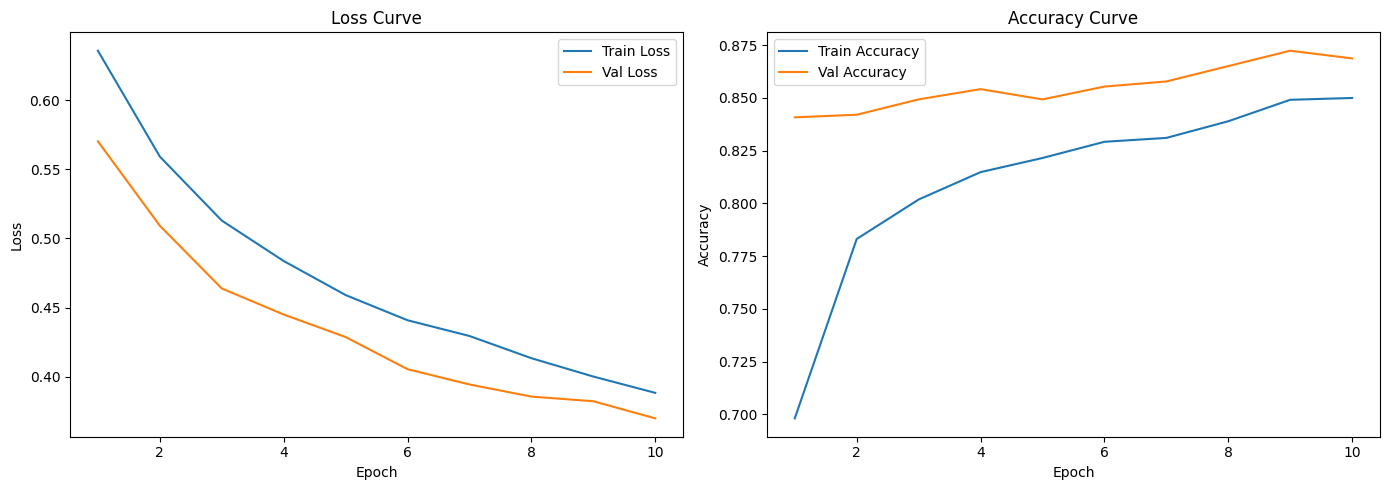

In [79]:
plot_training_curves(history)

### Tuning: Learning Rate

In [80]:
def make_model(lr=1e-4):
    model = FractureClassifierEfficientNet()
      
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
      
    return model, optimizer


==== Learning Rate: 3e-05 ====


Epoch 1/10
  Train Loss: 0.6750, Train Acc: 0.5902
  Val Loss: 0.6395, Val Acc: 0.7278
Checkpoint saved: checkpoints/fracture_classifierv2_epoch01_valacc0.728.pth
Epoch 2/10
  Train Loss: 0.6371, Train Acc: 0.6925
  Val Loss: 0.6100, Val Acc: 0.7667
Checkpoint saved: checkpoints/fracture_classifierv2_epoch02_valacc0.767.pth
Epoch 3/10
  Train Loss: 0.6099, Train Acc: 0.7345
  Val Loss: 0.5763, Val Acc: 0.8153
Checkpoint saved: checkpoints/fracture_classifierv2_epoch03_valacc0.815.pth
Epoch 4/10
  Train Loss: 0.5847, Train Acc: 0.7608
  Val Loss: 0.5419, Val Acc: 0.8287
Checkpoint saved: checkpoints/fracture_classifierv2_epoch04_valacc0.829.pth
Epoch 5/10
  Train Loss: 0.5658, Train Acc: 0.7714
  Val Loss: 0.5271, Val Acc: 0.8226
Epoch 6/10
  Train Loss: 0.5478, Train Acc: 0.7876
  Val Loss: 0.5183, Val Acc: 0.8408
Checkpoint saved: checkpoints/fracture_classifierv2_epoch06_valacc0.841.pth
Epoch 7/10
  Train Loss: 0.5329, Train Acc: 0.7895
  Val Loss: 0.5057, Val Acc: 0.8481
Checkpoint 

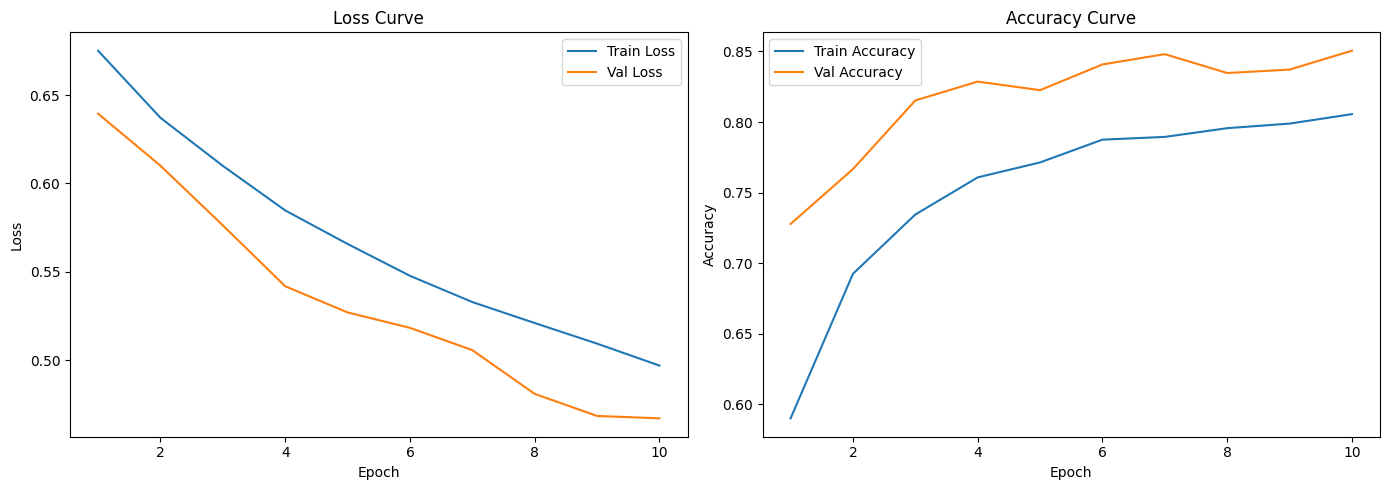


==== Learning Rate: 0.0001 ====
Epoch 1/10
  Train Loss: 0.6413, Train Acc: 0.6727
  Val Loss: 0.5702, Val Acc: 0.8177
Checkpoint saved: checkpoints/fracture_classifierv2_epoch01_valacc0.818.pth
Epoch 2/10
  Train Loss: 0.5611, Train Acc: 0.7825
  Val Loss: 0.5072, Val Acc: 0.8396
Checkpoint saved: checkpoints/fracture_classifierv2_epoch02_valacc0.840.pth
Epoch 3/10
  Train Loss: 0.5152, Train Acc: 0.7973
  Val Loss: 0.4664, Val Acc: 0.8360
Epoch 4/10
  Train Loss: 0.4846, Train Acc: 0.8087
  Val Loss: 0.4346, Val Acc: 0.8457
Checkpoint saved: checkpoints/fracture_classifierv2_epoch04_valacc0.846.pth
Epoch 5/10
  Train Loss: 0.4606, Train Acc: 0.8167
  Val Loss: 0.4244, Val Acc: 0.8578
Checkpoint saved: checkpoints/fracture_classifierv2_epoch05_valacc0.858.pth
Epoch 6/10
  Train Loss: 0.4391, Train Acc: 0.8341
  Val Loss: 0.4026, Val Acc: 0.8530
Epoch 7/10
  Train Loss: 0.4296, Train Acc: 0.8316
  Val Loss: 0.3945, Val Acc: 0.8615
Checkpoint saved: checkpoints/fracture_classifierv2_ep

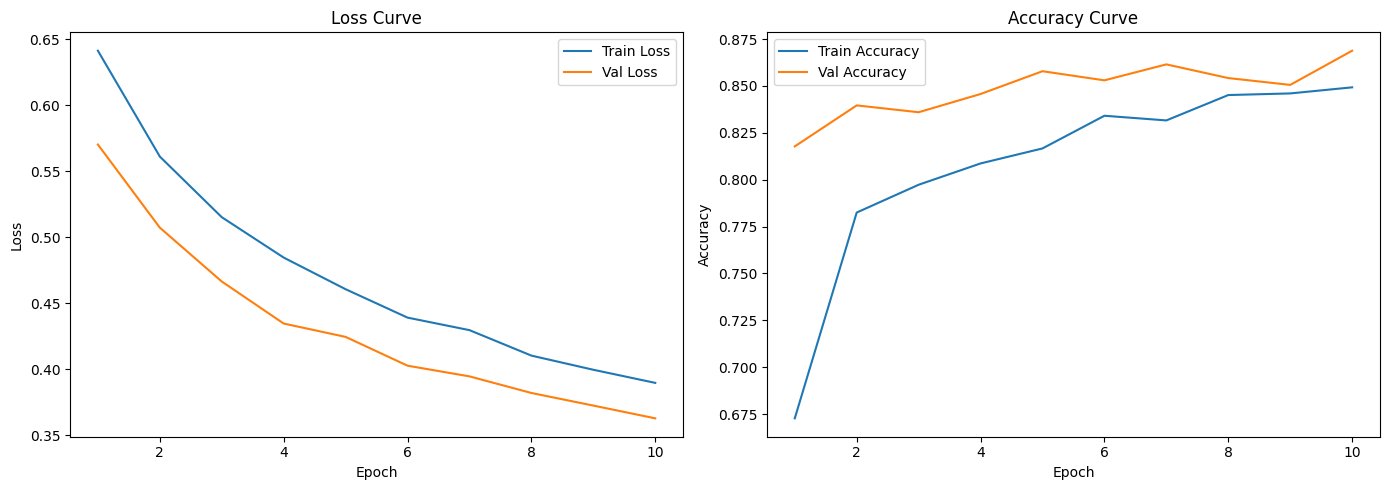


==== Learning Rate: 0.0003 ====
Epoch 1/10
  Train Loss: 0.5749, Train Acc: 0.7407
  Val Loss: 0.4646, Val Acc: 0.8311
Checkpoint saved: checkpoints/fracture_classifierv2_epoch01_valacc0.831.pth
Epoch 2/10
  Train Loss: 0.4656, Train Acc: 0.8156
  Val Loss: 0.4140, Val Acc: 0.8566
Checkpoint saved: checkpoints/fracture_classifierv2_epoch02_valacc0.857.pth
Epoch 3/10
  Train Loss: 0.4147, Train Acc: 0.8369
  Val Loss: 0.3697, Val Acc: 0.8736
Checkpoint saved: checkpoints/fracture_classifierv2_epoch03_valacc0.874.pth
Epoch 4/10
  Train Loss: 0.3864, Train Acc: 0.8490
  Val Loss: 0.3466, Val Acc: 0.8834
Checkpoint saved: checkpoints/fracture_classifierv2_epoch04_valacc0.883.pth
Epoch 5/10
  Train Loss: 0.3589, Train Acc: 0.8618
  Val Loss: 0.3327, Val Acc: 0.8894
Checkpoint saved: checkpoints/fracture_classifierv2_epoch05_valacc0.889.pth
Epoch 6/10
  Train Loss: 0.3431, Train Acc: 0.8672
  Val Loss: 0.3194, Val Acc: 0.8906
Checkpoint saved: checkpoints/fracture_classifierv2_epoch06_valac

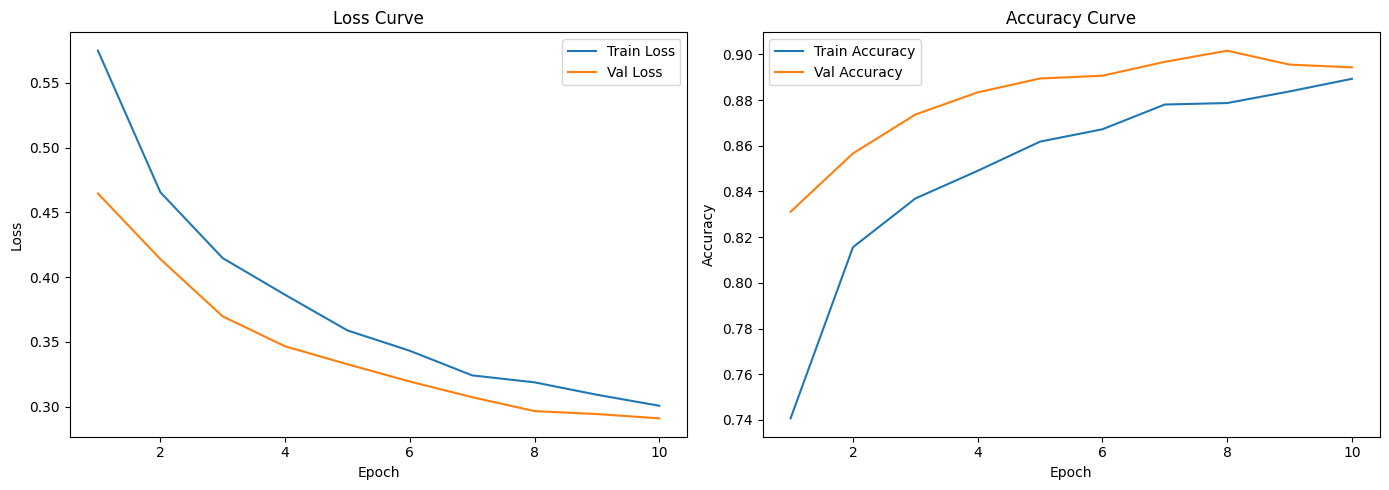


==== Learning Rate: 0.001 ====
Epoch 1/10
  Train Loss: 0.4806, Train Acc: 0.7924
  Val Loss: 0.3625, Val Acc: 0.8639
Checkpoint saved: checkpoints/fracture_classifierv2_epoch01_valacc0.864.pth
Epoch 2/10
  Train Loss: 0.3604, Train Acc: 0.8628
  Val Loss: 0.3182, Val Acc: 0.8785
Checkpoint saved: checkpoints/fracture_classifierv2_epoch02_valacc0.878.pth
Epoch 3/10
  Train Loss: 0.3190, Train Acc: 0.8754
  Val Loss: 0.2949, Val Acc: 0.9004
Checkpoint saved: checkpoints/fracture_classifierv2_epoch03_valacc0.900.pth
Epoch 4/10
  Train Loss: 0.2864, Train Acc: 0.8929
  Val Loss: 0.2669, Val Acc: 0.8931
Epoch 5/10
  Train Loss: 0.2733, Train Acc: 0.8955
  Val Loss: 0.2523, Val Acc: 0.9113
Checkpoint saved: checkpoints/fracture_classifierv2_epoch05_valacc0.911.pth
Epoch 6/10
  Train Loss: 0.2631, Train Acc: 0.8994
  Val Loss: 0.2443, Val Acc: 0.9089
Epoch 7/10
  Train Loss: 0.2539, Train Acc: 0.9034
  Val Loss: 0.2305, Val Acc: 0.9186
Checkpoint saved: checkpoints/fracture_classifierv2_epo

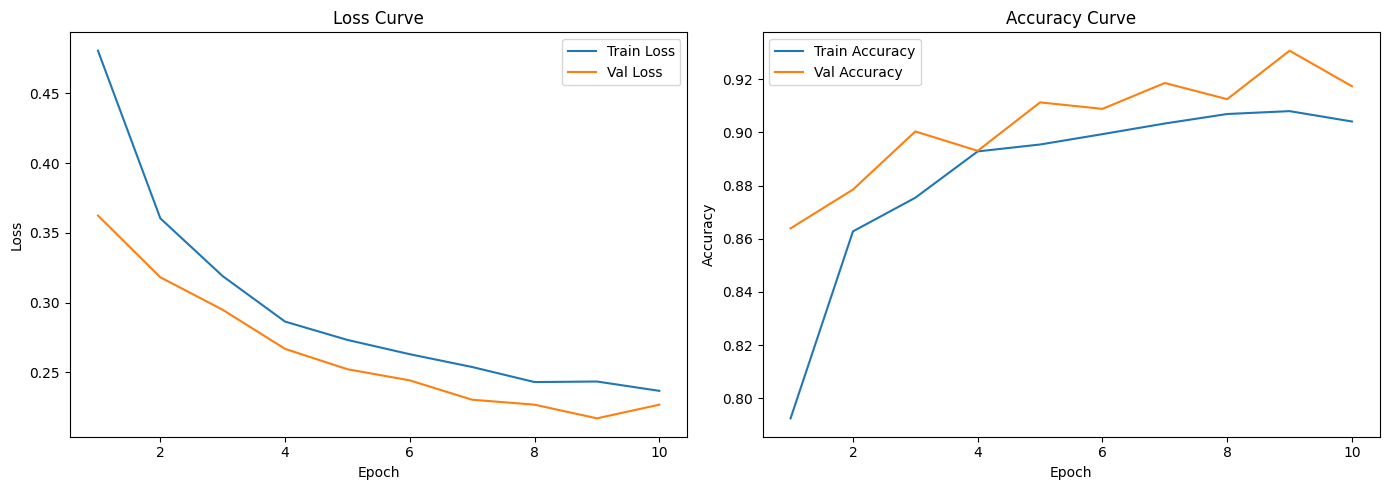

In [81]:
learning_rates = [3e-5, 1e-4, 3e-4, 1e-3]
num_epochs=10

for lr in learning_rates:
    print(f'\n==== Learning Rate: {lr} ====')
    model, optimizer = make_model(lr=lr)
    history = train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device, version='v2')
    plot_training_curves(history)

lr = 1e-3 converges quickly and gives highest validation accuracy. Will proceed with this value. While 0.001 is high, it is evidently not causing instability so is still justified.

In [82]:
lr = 0.001

### Tuning: Adding more inner layers

The previous method showed just the final layer being modified from EfficientNet. Now I will add a small trainable head on top of the frozen backbone.

In [83]:
class FractureClassifierEfficientNet(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        #Load pretrained model
        self.base_model = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )

        #Freeze base model
        for param in self.base_model.parameters():
            param.requires_grad = False

        #take the last layer of efficientnet as output
        in_features = self.base_model.classifier[1].in_features

        #replace classifier head
        self.base_model.classifier = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1))

    def forward(self, x):
        return self.base_model(x)

In [85]:
def make_model(hidden_dim, lr=lr):
    model = FractureClassifierEfficientNet(hidden_dim=hidden_dim)
      
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
      
    return model, optimizer


=== Training with hidden_dim=128 ===
Epoch 1/10
  Train Loss: 0.3040, Train Acc: 0.8736
  Val Loss: 0.1782, Val Acc: 0.9344
Checkpoint saved: checkpoints/fracture_classifierv3_epoch01_valacc0.934.pth
Epoch 2/10
  Train Loss: 0.1367, Train Acc: 0.9504
  Val Loss: 0.1116, Val Acc: 0.9526
Checkpoint saved: checkpoints/fracture_classifierv3_epoch02_valacc0.953.pth
Epoch 3/10
  Train Loss: 0.0790, Train Acc: 0.9737
  Val Loss: 0.0832, Val Acc: 0.9660
Checkpoint saved: checkpoints/fracture_classifierv3_epoch03_valacc0.966.pth
Epoch 4/10
  Train Loss: 0.0590, Train Acc: 0.9792
  Val Loss: 0.0489, Val Acc: 0.9830
Checkpoint saved: checkpoints/fracture_classifierv3_epoch04_valacc0.983.pth
Epoch 5/10
  Train Loss: 0.0408, Train Acc: 0.9871
  Val Loss: 0.0523, Val Acc: 0.9830
Epoch 6/10
  Train Loss: 0.0300, Train Acc: 0.9903
  Val Loss: 0.0504, Val Acc: 0.9793
Epoch 7/10
  Train Loss: 0.0308, Train Acc: 0.9898
  Val Loss: 0.0371, Val Acc: 0.9854
Checkpoint saved: checkpoints/fracture_classifier

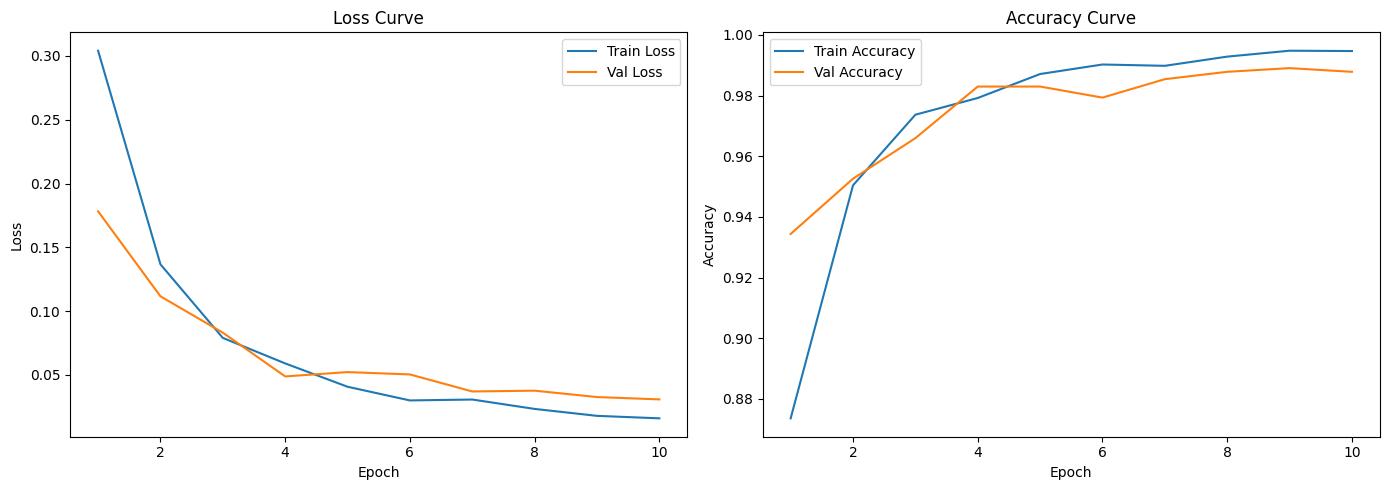


=== Training with hidden_dim=256 ===
Epoch 1/10
  Train Loss: 0.2627, Train Acc: 0.8933
  Val Loss: 0.1545, Val Acc: 0.9441
Checkpoint saved: checkpoints/fracture_classifierv3_epoch01_valacc0.944.pth
Epoch 2/10
  Train Loss: 0.0932, Train Acc: 0.9670
  Val Loss: 0.1198, Val Acc: 0.9502
Checkpoint saved: checkpoints/fracture_classifierv3_epoch02_valacc0.950.pth
Epoch 3/10
  Train Loss: 0.0555, Train Acc: 0.9811
  Val Loss: 0.0593, Val Acc: 0.9769
Checkpoint saved: checkpoints/fracture_classifierv3_epoch03_valacc0.977.pth
Epoch 4/10
  Train Loss: 0.0360, Train Acc: 0.9879
  Val Loss: 0.0404, Val Acc: 0.9915
Checkpoint saved: checkpoints/fracture_classifierv3_epoch04_valacc0.991.pth
Epoch 5/10
  Train Loss: 0.0310, Train Acc: 0.9903
  Val Loss: 0.0277, Val Acc: 0.9915
Epoch 6/10
  Train Loss: 0.0209, Train Acc: 0.9929
  Val Loss: 0.0252, Val Acc: 0.9903
Epoch 7/10
  Train Loss: 0.0189, Train Acc: 0.9939
  Val Loss: 0.0186, Val Acc: 0.9939
Checkpoint saved: checkpoints/fracture_classifier

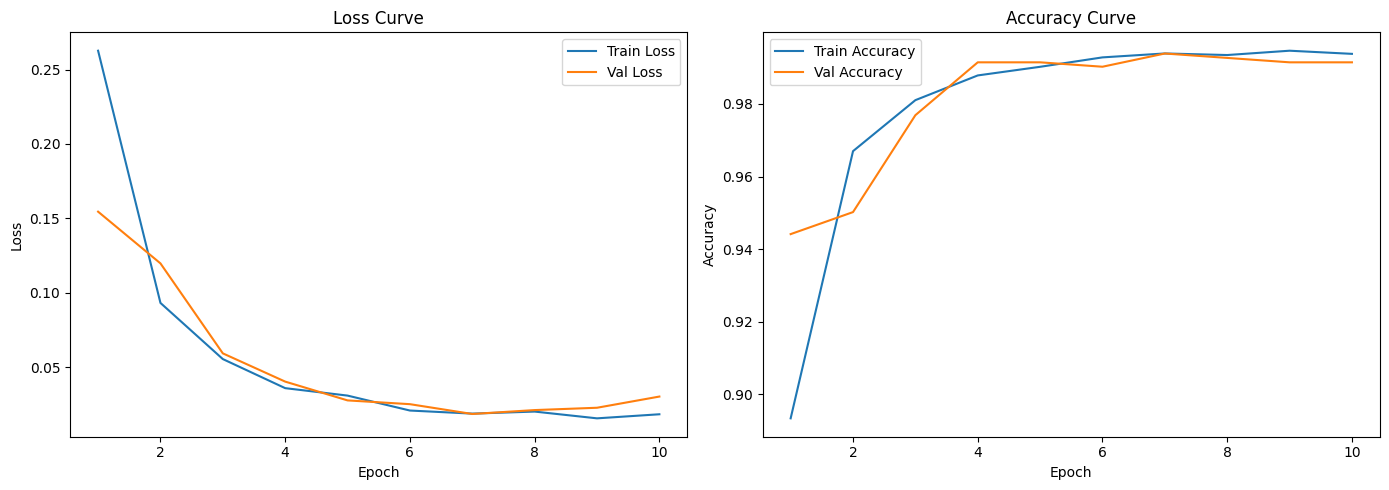


=== Training with hidden_dim=512 ===
Epoch 1/10
  Train Loss: 0.2329, Train Acc: 0.9034
  Val Loss: 0.1152, Val Acc: 0.9502
Checkpoint saved: checkpoints/fracture_classifierv3_epoch01_valacc0.950.pth
Epoch 2/10
  Train Loss: 0.0708, Train Acc: 0.9762
  Val Loss: 0.0693, Val Acc: 0.9708
Checkpoint saved: checkpoints/fracture_classifierv3_epoch02_valacc0.971.pth
Epoch 3/10
  Train Loss: 0.0399, Train Acc: 0.9882
  Val Loss: 0.0456, Val Acc: 0.9818
Checkpoint saved: checkpoints/fracture_classifierv3_epoch03_valacc0.982.pth
Epoch 4/10
  Train Loss: 0.0285, Train Acc: 0.9899
  Val Loss: 0.0416, Val Acc: 0.9793
Epoch 5/10
  Train Loss: 0.0221, Train Acc: 0.9925
  Val Loss: 0.0196, Val Acc: 0.9939
Checkpoint saved: checkpoints/fracture_classifierv3_epoch05_valacc0.994.pth
Epoch 6/10
  Train Loss: 0.0198, Train Acc: 0.9938
  Val Loss: 0.0338, Val Acc: 0.9878
Epoch 7/10
  Train Loss: 0.0185, Train Acc: 0.9936
  Val Loss: 0.0271, Val Acc: 0.9915
Epoch 8/10
  Train Loss: 0.0133, Train Acc: 0.994

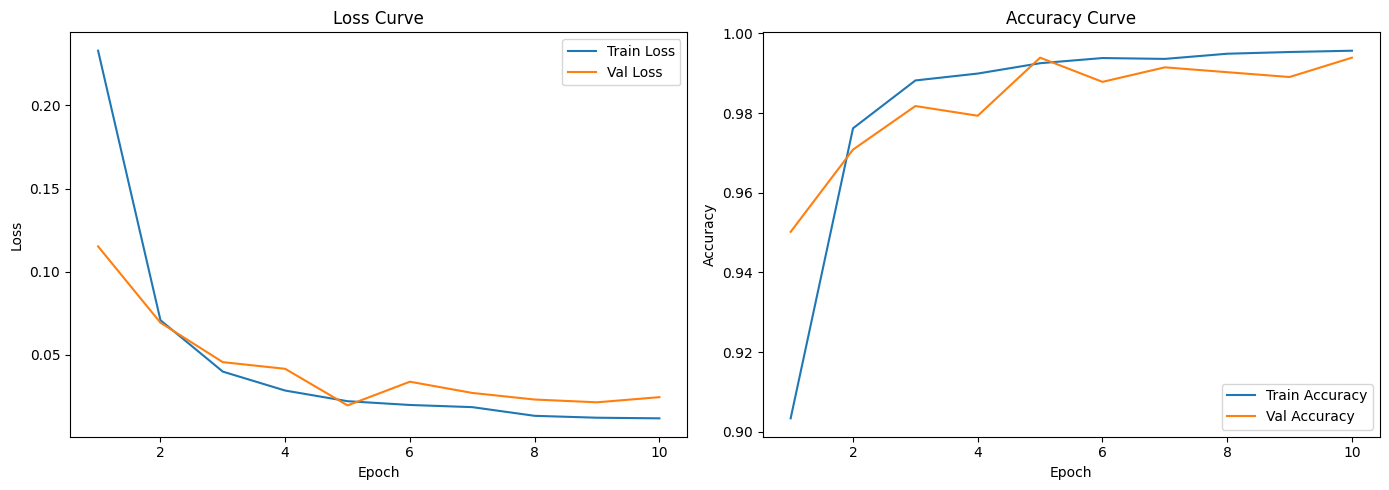

In [87]:
#trying different inner layer sizes:

for hidden_dim in [128, 256, 512]:
    print(f"\n=== Training with hidden_dim={hidden_dim} ===")
    
    model, optimizer = make_model(
        hidden_dim=hidden_dim,
        lr=lr
    )
    
    history = train_and_evaluate(
        model,
        optimizer,
        train_loader,
        val_loader,
        criterion,
        num_epochs=10,
        device=device,
        version='v3'
    )

    plot_training_curves(history)

256 and 512 have the highest validation accuracies, but 512 is the safer choice. 512 shows a bit of overfitting.

In [88]:
hidden_dim = 256

### Tuning: Adding Dropout Regularization

In [94]:
class FractureClassifierEfficientNet(nn.Module):
    def __init__(self, hidden_dim, droprate=0.2):
        super().__init__()

        #Load pretrained model
        self.base_model = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )

        #Freeze base model
        for param in self.base_model.parameters():
            param.requires_grad = False

        #take the last layer of efficientnet as output
        in_features = self.base_model.classifier[1].in_features

        #replace classifier head
        self.base_model.classifier = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(),
            nn.Dropout(droprate),
            nn.Linear(hidden_dim, 1))

    def forward(self, x):
        return self.base_model(x)

In [90]:
def make_model(hidden_dim=hidden_dim, lr=lr, droprate=0.2):
    model = FractureClassifierEfficientNet(hidden_dim=hidden_dim, droprate=droprate)
      
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
      
    return model, optimizer


=== Training with droprate=0.2 ===
Epoch 1/10
  Train Loss: 0.2796, Train Acc: 0.8813
  Val Loss: 0.1605, Val Acc: 0.9380
Checkpoint saved: checkpoints/fracture_classifierv4_epoch01_valacc0.938.pth
Epoch 2/10
  Train Loss: 0.1075, Train Acc: 0.9617
  Val Loss: 0.1040, Val Acc: 0.9599
Checkpoint saved: checkpoints/fracture_classifierv4_epoch02_valacc0.960.pth
Epoch 3/10
  Train Loss: 0.0581, Train Acc: 0.9806
  Val Loss: 0.0614, Val Acc: 0.9769
Checkpoint saved: checkpoints/fracture_classifierv4_epoch03_valacc0.977.pth
Epoch 4/10
  Train Loss: 0.0443, Train Acc: 0.9851
  Val Loss: 0.0490, Val Acc: 0.9830
Checkpoint saved: checkpoints/fracture_classifierv4_epoch04_valacc0.983.pth
Epoch 5/10
  Train Loss: 0.0324, Train Acc: 0.9895
  Val Loss: 0.0534, Val Acc: 0.9745
Epoch 6/10
  Train Loss: 0.0269, Train Acc: 0.9923
  Val Loss: 0.0310, Val Acc: 0.9915
Checkpoint saved: checkpoints/fracture_classifierv4_epoch06_valacc0.991.pth
Epoch 7/10
  Train Loss: 0.0218, Train Acc: 0.9933
  Val Loss:

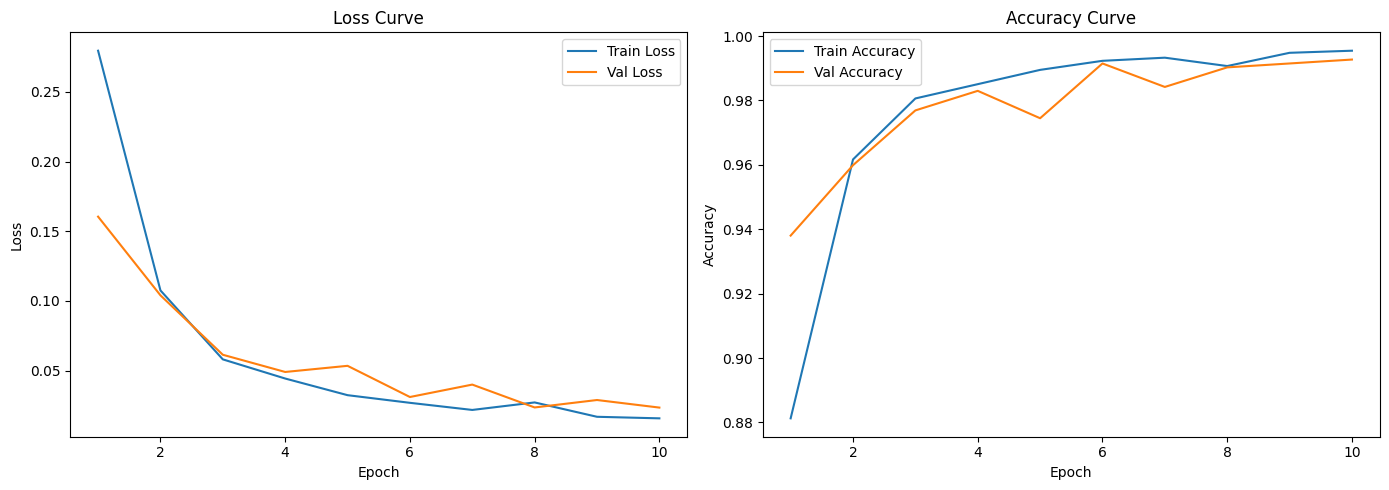


=== Training with droprate=0.3 ===
Epoch 1/10
  Train Loss: 0.2792, Train Acc: 0.8832
  Val Loss: 0.1509, Val Acc: 0.9441
Checkpoint saved: checkpoints/fracture_classifierv4_epoch01_valacc0.944.pth
Epoch 2/10
  Train Loss: 0.1113, Train Acc: 0.9611
  Val Loss: 0.0817, Val Acc: 0.9733
Checkpoint saved: checkpoints/fracture_classifierv4_epoch02_valacc0.973.pth
Epoch 3/10
  Train Loss: 0.0654, Train Acc: 0.9779
  Val Loss: 0.0636, Val Acc: 0.9781
Checkpoint saved: checkpoints/fracture_classifierv4_epoch03_valacc0.978.pth
Epoch 4/10
  Train Loss: 0.0455, Train Acc: 0.9857
  Val Loss: 0.0457, Val Acc: 0.9866
Checkpoint saved: checkpoints/fracture_classifierv4_epoch04_valacc0.987.pth
Epoch 5/10
  Train Loss: 0.0397, Train Acc: 0.9859
  Val Loss: 0.0378, Val Acc: 0.9878
Checkpoint saved: checkpoints/fracture_classifierv4_epoch05_valacc0.988.pth
Epoch 6/10
  Train Loss: 0.0309, Train Acc: 0.9896
  Val Loss: 0.0229, Val Acc: 0.9964
Checkpoint saved: checkpoints/fracture_classifierv4_epoch06_va

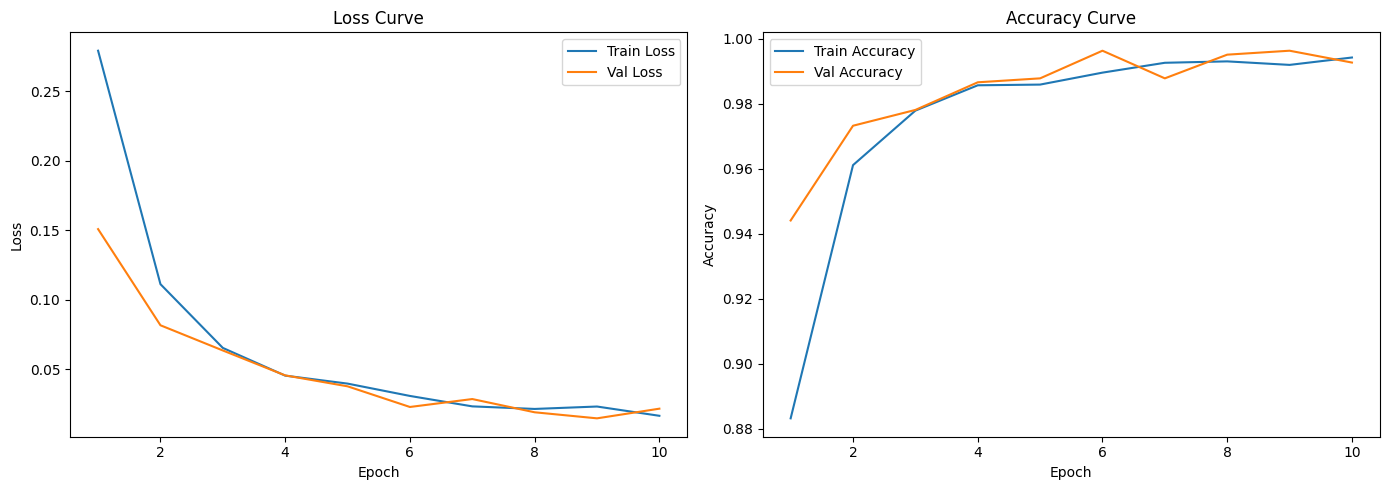


=== Training with droprate=0.5 ===
Epoch 1/10
  Train Loss: 0.3185, Train Acc: 0.8663
  Val Loss: 0.1640, Val Acc: 0.9514
Checkpoint saved: checkpoints/fracture_classifierv4_epoch01_valacc0.951.pth
Epoch 2/10
  Train Loss: 0.1400, Train Acc: 0.9516
  Val Loss: 0.1077, Val Acc: 0.9660
Checkpoint saved: checkpoints/fracture_classifierv4_epoch02_valacc0.966.pth
Epoch 3/10
  Train Loss: 0.0865, Train Acc: 0.9706
  Val Loss: 0.0878, Val Acc: 0.9635
Epoch 4/10
  Train Loss: 0.0636, Train Acc: 0.9780
  Val Loss: 0.0902, Val Acc: 0.9587
Epoch 5/10
  Train Loss: 0.0522, Train Acc: 0.9818
  Val Loss: 0.0564, Val Acc: 0.9793
Checkpoint saved: checkpoints/fracture_classifierv4_epoch05_valacc0.979.pth
Epoch 6/10
  Train Loss: 0.0411, Train Acc: 0.9873
  Val Loss: 0.0426, Val Acc: 0.9806
Checkpoint saved: checkpoints/fracture_classifierv4_epoch06_valacc0.981.pth
Epoch 7/10
  Train Loss: 0.0382, Train Acc: 0.9865
  Val Loss: 0.0396, Val Acc: 0.9830
Checkpoint saved: checkpoints/fracture_classifierv4

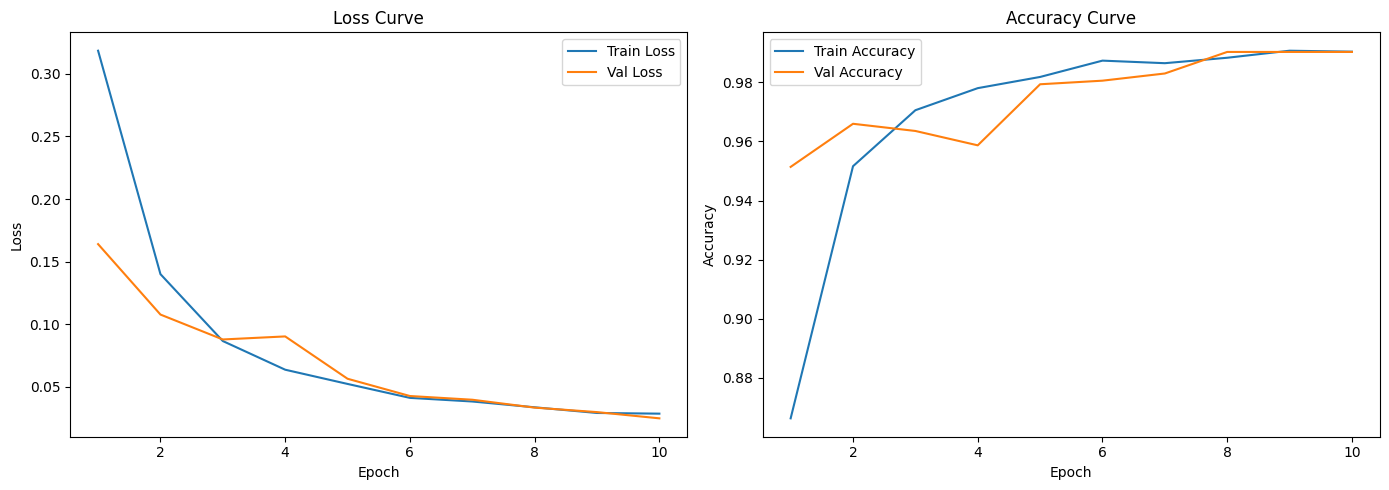

In [91]:
for droprate in [0.2, 0.3, 0.5]:
    print(f"\n=== Training with droprate={droprate} ===")
    
    model, optimizer = make_model(
        hidden_dim=hidden_dim,
        lr=lr,
        droprate=droprate
    )
    
    history = train_and_evaluate(
        model,
        optimizer,
        train_loader,
        val_loader,
        criterion,
        num_epochs=10,
        device=device,
        version='v4'
    )

    plot_training_curves(history)

droprate=0.2 has slight overfitting, 0.5 underfits in the begginning, although it is still stable, but 0.3 clearly has the least overfitting and the most stability.

In [ ]:
droprate = 0.3

### Final Model

will train for 50 epochs, but include early stopping with a patience of 5, since the model was already performing very well after 10 epochs.

In [98]:
# TRAINING LOOP

def train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device, version='v5', patience=5):
    best_val_acc = 0.0
    best_val_loss = float('inf')
    patience_counter = 0
    
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.float().to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels.unsqueeze(1))

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            preds = (torch.sigmoid(outputs) > 0.5).float()

            total += labels.size(0)
            correct += (preds.squeeze() == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels.unsqueeze(1))

                val_loss += loss.item()
                preds = (torch.sigmoid(outputs) > 0.5).float()
                
                val_total += labels.size(0)
                val_correct += (preds.squeeze() == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total

        # Store history 
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
        print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

        #checkpointing
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            checkpoint_pth = f'checkpoints/fracture_classifier{version}_epoch{epoch+1:02d}_valacc{val_acc:.3f}.pth'
            torch.save(model.state_dict(), checkpoint_pth)
            print(f'Checkpoint saved: {checkpoint_pth}')
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else: patience_counter += 1

        if patience_counter >= patience:
            print(f'Early stopping triggered after {epoch+1} epochs.')
            print(f'Best performance: loss: {best_val_loss:.4f}, accuracy: {best_val_acc:.4f}')
            break
        
    return history

In [99]:
lr = 0.001
hidden_dim = 256
droprate = 0.3
num_epochs = 50

model, optimizer = make_model(lr=lr, hidden_dim=hidden_dim, droprate=droprate)

Epoch 1/50
  Train Loss: 0.2853, Train Acc: 0.8791
  Val Loss: 0.1467, Val Acc: 0.9417
Checkpoint saved: checkpoints/fracture_classifierv5_epoch01_valacc0.942.pth
Epoch 2/50
  Train Loss: 0.1102, Train Acc: 0.9602
  Val Loss: 0.0891, Val Acc: 0.9696
Checkpoint saved: checkpoints/fracture_classifierv5_epoch02_valacc0.970.pth
Epoch 3/50
  Train Loss: 0.0654, Train Acc: 0.9792
  Val Loss: 0.0600, Val Acc: 0.9769
Checkpoint saved: checkpoints/fracture_classifierv5_epoch03_valacc0.977.pth
Epoch 4/50
  Train Loss: 0.0485, Train Acc: 0.9839
  Val Loss: 0.0461, Val Acc: 0.9842
Checkpoint saved: checkpoints/fracture_classifierv5_epoch04_valacc0.984.pth
Epoch 5/50
  Train Loss: 0.0357, Train Acc: 0.9886
  Val Loss: 0.0331, Val Acc: 0.9842
Epoch 6/50
  Train Loss: 0.0319, Train Acc: 0.9894
  Val Loss: 0.0272, Val Acc: 0.9903
Checkpoint saved: checkpoints/fracture_classifierv5_epoch06_valacc0.990.pth
Epoch 7/50
  Train Loss: 0.0275, Train Acc: 0.9916
  Val Loss: 0.0276, Val Acc: 0.9915
Checkpoint 

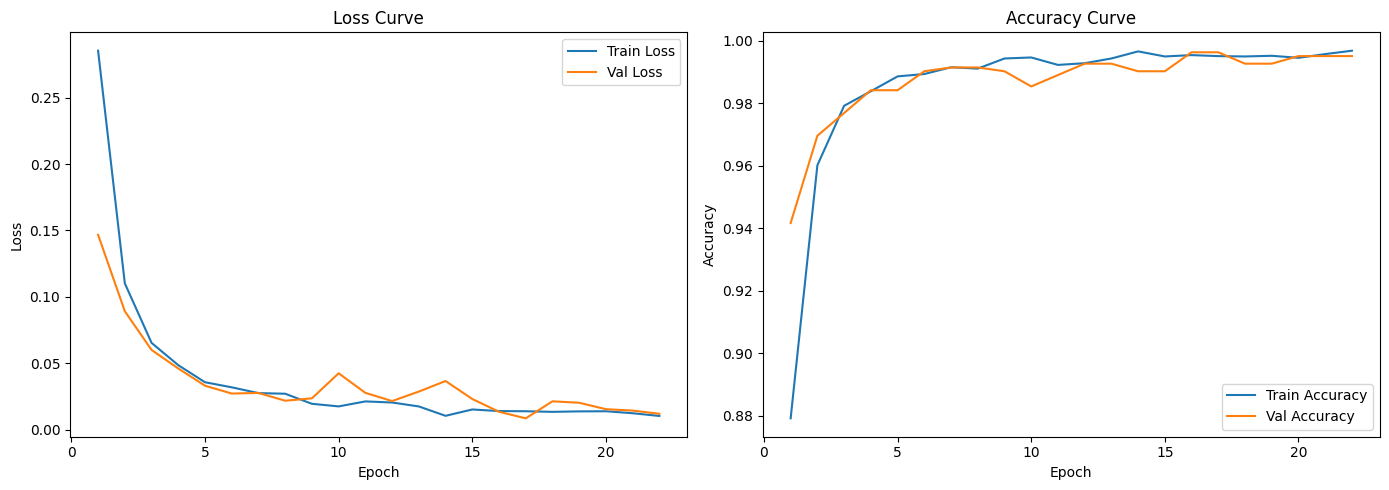

In [100]:
history = train_and_evaluate(
    model,
    optimizer,
    train_loader,
    val_loader,
    criterion,
    num_epochs=num_epochs,
    device=device,
    version='v5'
)

plot_training_curves(history)

### Using Model on Test Dataset

In [101]:
best_checkpoint = 'checkpoints/fracture_classifierv5_epoch16_valacc0.996.pth'
model.load_state_dict(torch.load(best_checkpoint))
model.eval()

FractureClassifierEfficientNet(
  (base_model): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)


In [105]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.float().to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels.unsqueeze(1))
            test_loss += loss.item()

            probs = torch.sigmoid(outputs).squeeze()
            preds = (probs > 0.5).float()

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    test_loss /= len(dataloader)
    test_acc = correct / total

    return test_loss, test_acc


In [107]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")


Test Loss: 0.0327
Test Accuracy:  0.9920
